## Synthetic Data

In [ ]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from cd.algs.basis_projection import BasisProjector

In [127]:
N, T, D = 10, 100, 2
# Creating synthetic data (sine waves with noise)
t = np.linspace(0, 1, T)
demos = []
for _ in range(N):
    noise = np.random.normal(0, 0.05, (T, D))
    # Joint 1: Sine, Joint 2: Cosine
    traj = np.column_stack([np.sin(2*np.pi*t), np.cos(2*np.pi*t)]) + noise
    demos.append(traj)

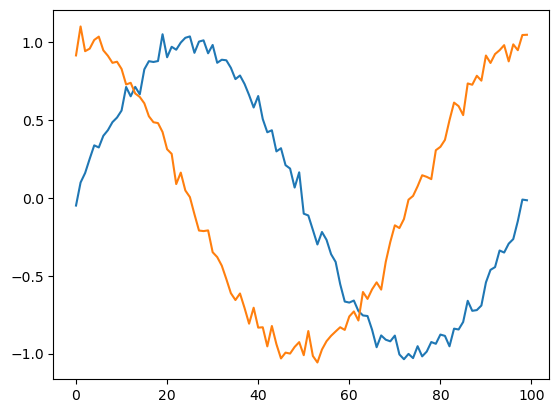

In [128]:
plt.plot(demos[3])

In [129]:
proj = BasisProjector(n_dims=D, n_basis=5, basis_type='gaussian')

# Project demos into weight space and fit a Gaussian for scoring
W = proj.project(np.array(demos), t)
weights = W.reshape(len(demos), -1)

mu_w = np.mean(weights, axis=0)
sigma_w = np.cov(weights, rowvar=False)
inv_sigma_w = np.linalg.inv(sigma_w + 1e-6 * np.eye(len(mu_w)))

Normal Score: 7.78
Anomaly Score: 139914.08


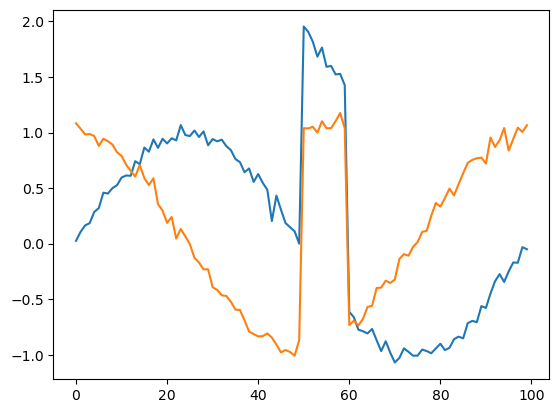

In [130]:
bad_traj = demos[0].copy()
bad_traj[50:60, :] += 2.0 # Sudden jerk

plt.plot(bad_traj)

def mahalanobis_score(traj):
    w = proj.project(traj[np.newaxis], t).ravel()
    diff = w - mu_w
    return diff.T @ inv_sigma_w @ diff

score_normal = mahalanobis_score(demos[0])
score_anomaly = mahalanobis_score(bad_traj)

print(f"Normal Score: {score_normal:.2f}")   # Low (e.g., 20.5)
print(f"Anomaly Score: {score_anomaly:.2f}") # High (e.g., 5000.0)

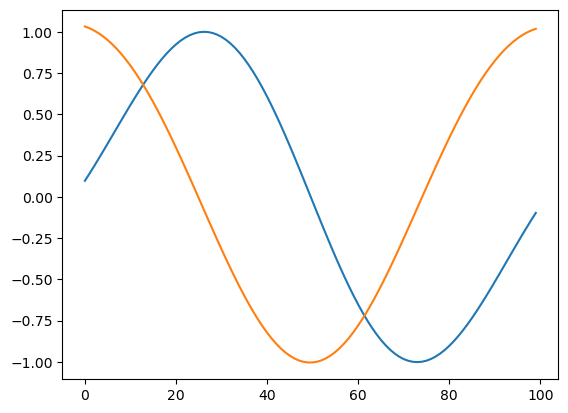

In [131]:
Phi = proj.basis.evaluate(t)
mean_traj_flat = Phi @ mu_w
mean_traj = mean_traj_flat.reshape(D, T).T

plt.plot(mean_traj)

## Real-Data Exploration: Basis Reconstruction Across Environments

How well do the four basis types (Gaussian, von Mises, B-spline, Fourier) reconstruct trajectory windows from each robot environment? We use the same hyperparameters as the `basis` detector config: `n_basis=5`, `window_frac=0.1`, `ridge_lambda=1e1`.

In [132]:
from config.tasks import TASK_CONFIGS
from config.envs import ENV_INFO
from tasks.fold_task import create_fold_tasks
from cd.utils.windows import strided_window_view
import pandas as pd

# Basis detector hyperparameters
N_BASIS = 10
WINDOW_FRAC = 0.05
RIDGE_LAMBDA = 1e-8
BASIS_TYPES = ['gaussian', 'vonmises', 'bspline', 'fourier']
MAX_PLOT_DIMS = 4
N_EXAMPLE_WINDOWS = 1

# Environments ordered by obs_dim
ENV_ORDER = ['inv_pend', 'upkie', 'hopper', 'half_cheetah', 'ant', 'humanoid']

In [133]:
env_data = {}

for env_name in ENV_ORDER:
    cfg = TASK_CONFIGS[env_name]
    info = ENV_INFO[env_name]
    try:
        tasks = create_fold_tasks(cfg, n_folds=5, seed=42)
        x_train, _ = tasks[0].get_train_test(verbose=False)
    except Exception as e:
        print(f"Skipping {info.display_name}: {e}")
        continue

    # x_train is already per-channel standardized by FoldTask.get_train_test()
    n_episodes, ep_len, obs_dim = x_train.shape
    window = max(10, int(ep_len * WINDOW_FRAC))
    stride = max(1, window // 2)

    # Skip initial transient (matches BasisDetector._fit_impl)
    x_trimmed = x_train[:, window:, :]
    all_windows = strided_window_view(x_trimmed, window=window, stride=stride)
    all_windows = all_windows.reshape(-1, window, obs_dim)

    plot_dims = np.arange(min(MAX_PLOT_DIMS, obs_dim))

    # Pick 2 deterministic example windows
    rng = np.random.default_rng(42)
    example_idx = rng.choice(len(all_windows), size=N_EXAMPLE_WINDOWS, replace=False)
    example_windows = all_windows[example_idx]

    env_data[env_name] = {
        'all_windows': all_windows,
        'example_windows': example_windows,
        'plot_dims': plot_dims,
        'window': window,
        'obs_dim': obs_dim,
        'display_name': info.display_name,
    }
    print(f"{info.display_name}: {all_windows.shape[0]} windows, "
          f"window={window}, obs_dim={obs_dim}, plot_dims={list(plot_dims)}")

Inv. Pend.: 21571 windows, window=50, obs_dim=4, plot_dims=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Upkie: 26233 windows, window=50, obs_dim=4, plot_dims=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Hopper: 8251 windows, window=50, obs_dim=11, plot_dims=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Half Cheetah: 21608 windows, window=50, obs_dim=17, plot_dims=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Ant: 11322 windows, window=50, obs_dim=105, plot_dims=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Humanoid: 18056 windows, window=50, obs_dim=348, plot_dims=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [134]:
def reconstruct_all_bases(windows, obs_dim, window_len):
    """Reconstruct windows using each basis type.

    Args:
        windows: (N, T, D) array of trajectory windows.
        obs_dim: number of observation dimensions.
        window_len: length of each window (T).

    Returns:
        dict mapping basis_type -> (N, T, D) reconstructions.
    """
    time_points = np.linspace(0, 1, window_len)
    reconstructions = {}
    for btype in BASIS_TYPES:
        proj = BasisProjector(
            n_dims=obs_dim,
            n_basis=N_BASIS,
            basis_type=btype,
            ridge_lambda=RIDGE_LAMBDA,
        )
        W = proj.project(windows, time_points)  # (N, D, K)
        Phi = proj.basis._compute_basis_single(time_points)  # (T, K)
        recon = np.einsum('tk,ndk->ntd', Phi, W)  # (N, T, D)
        reconstructions[btype] = recon
    return reconstructions

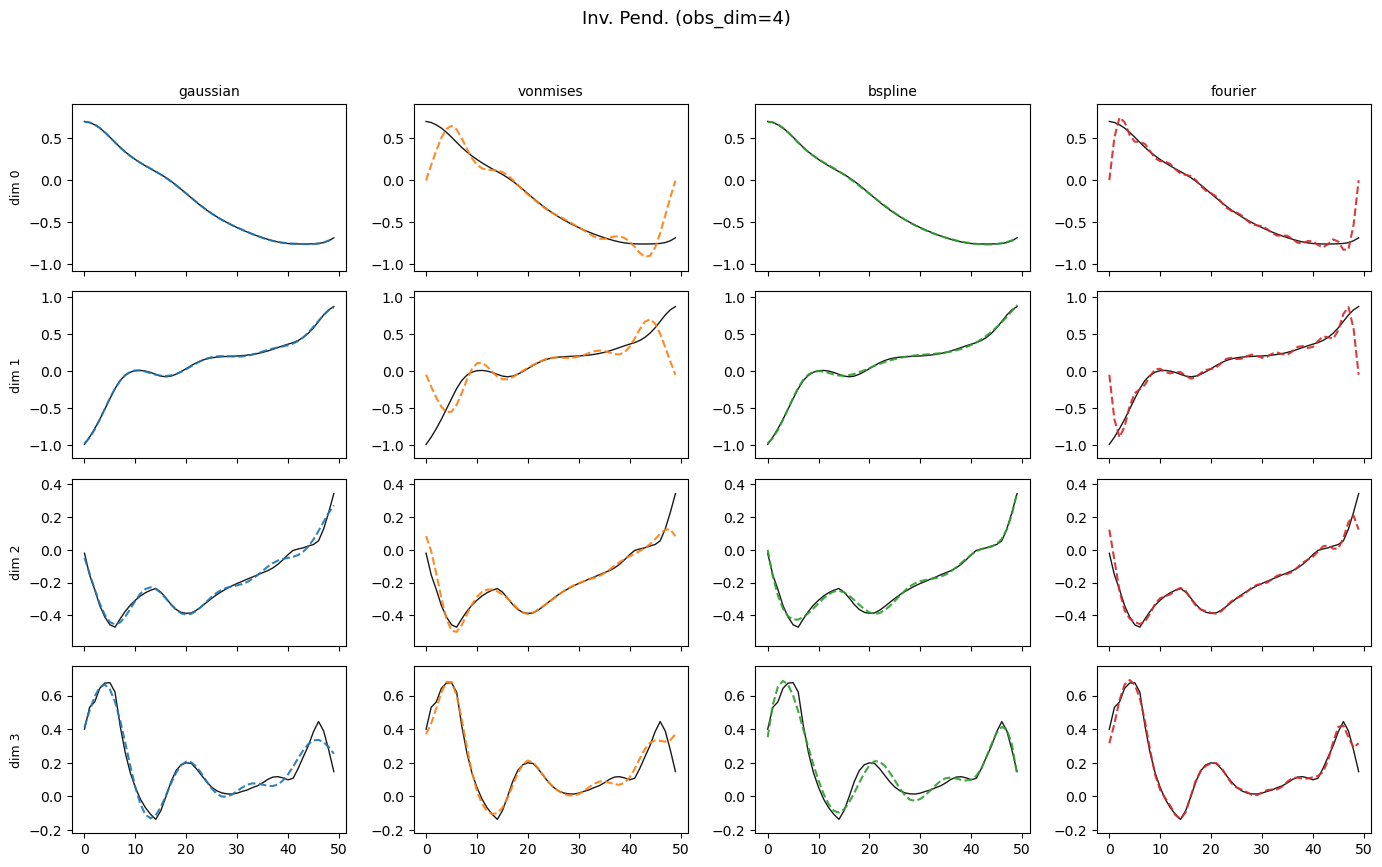

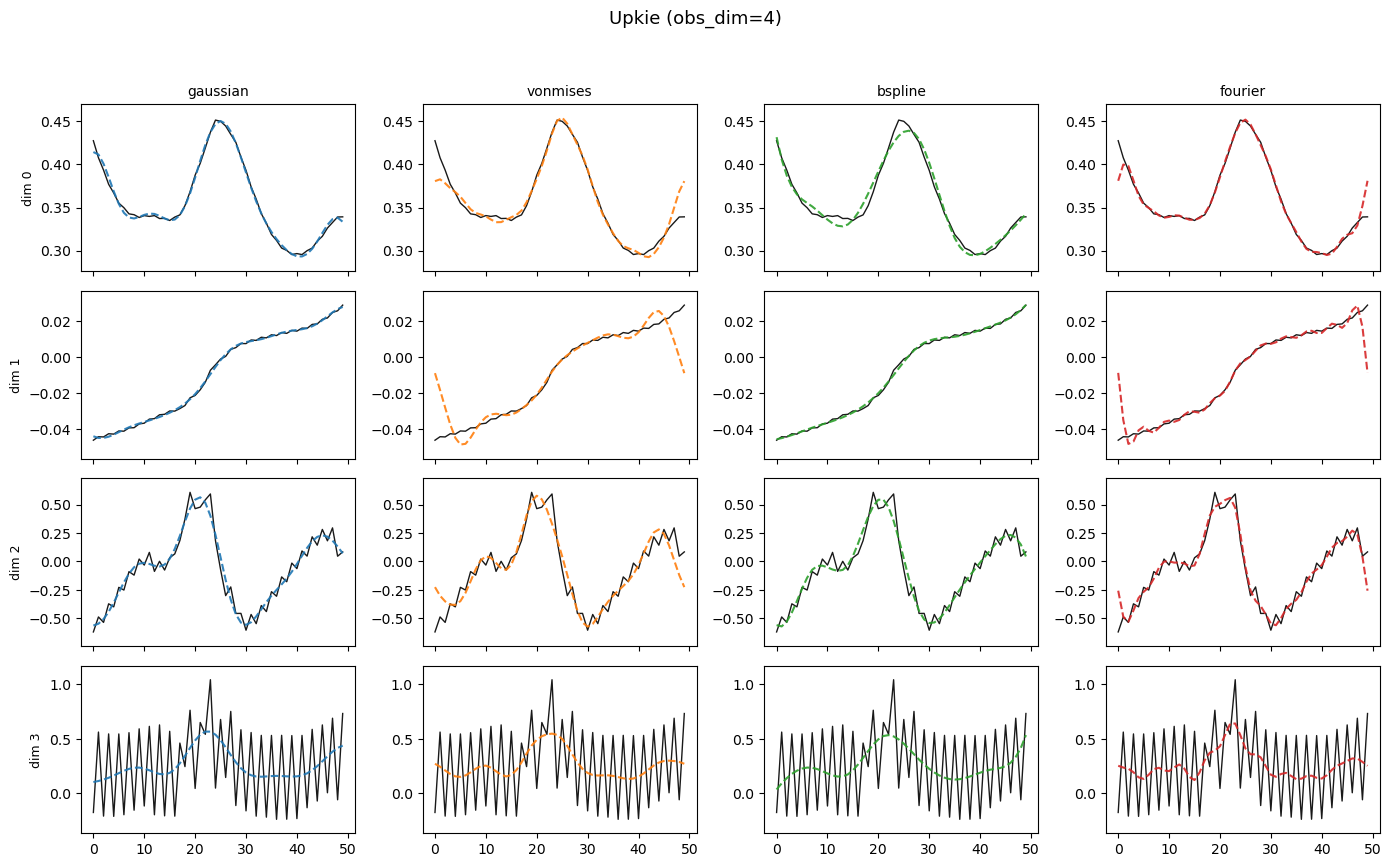

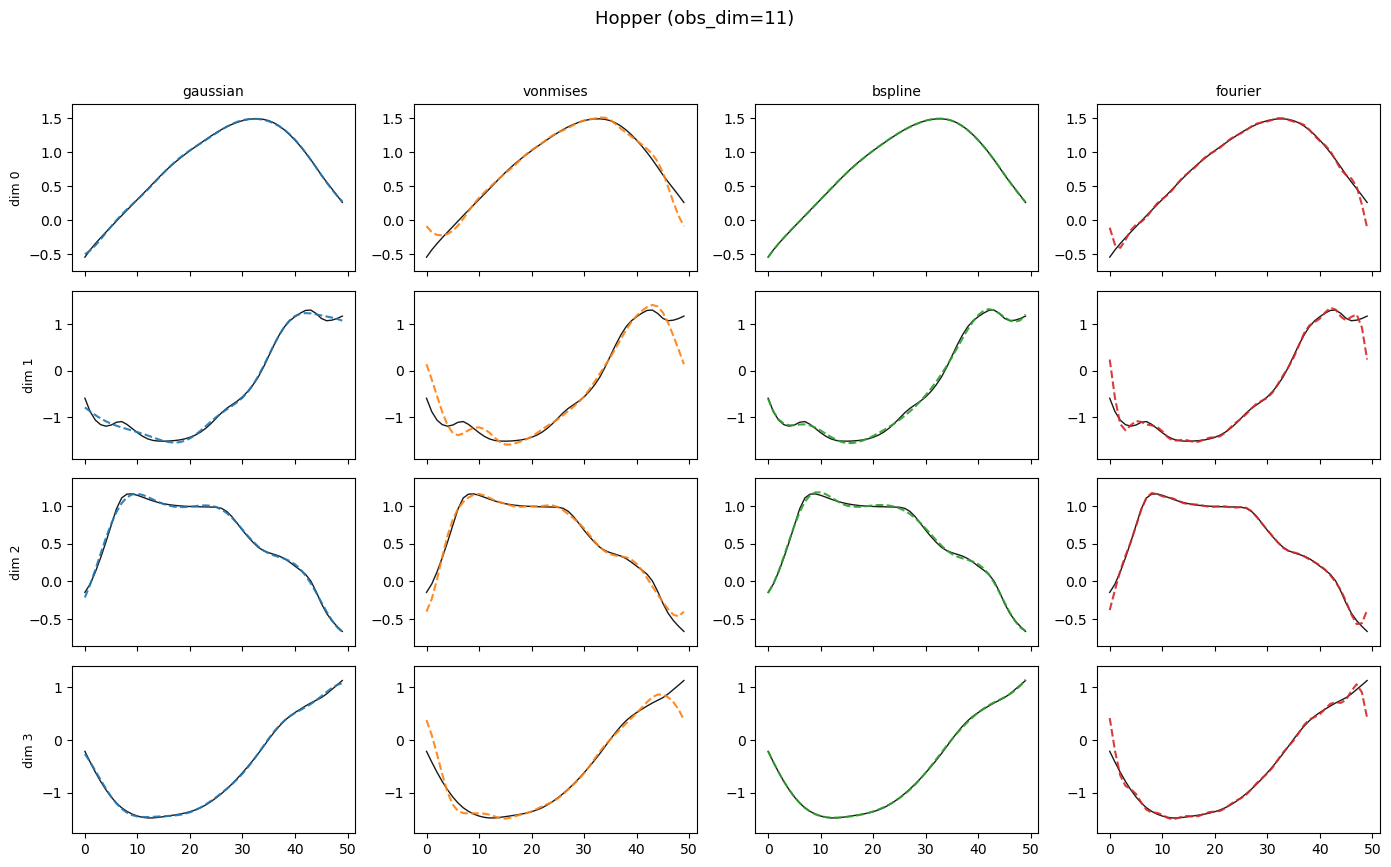

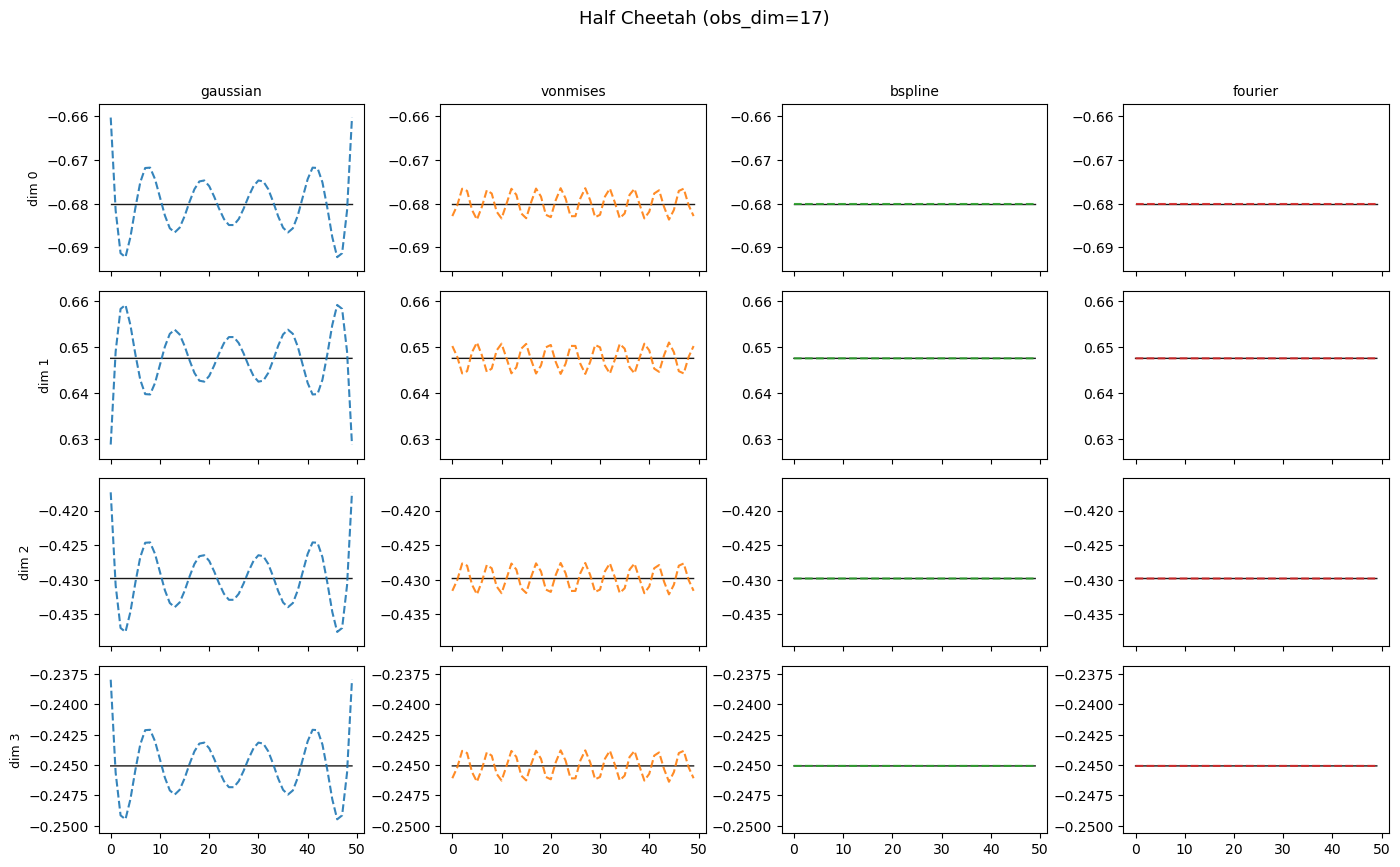

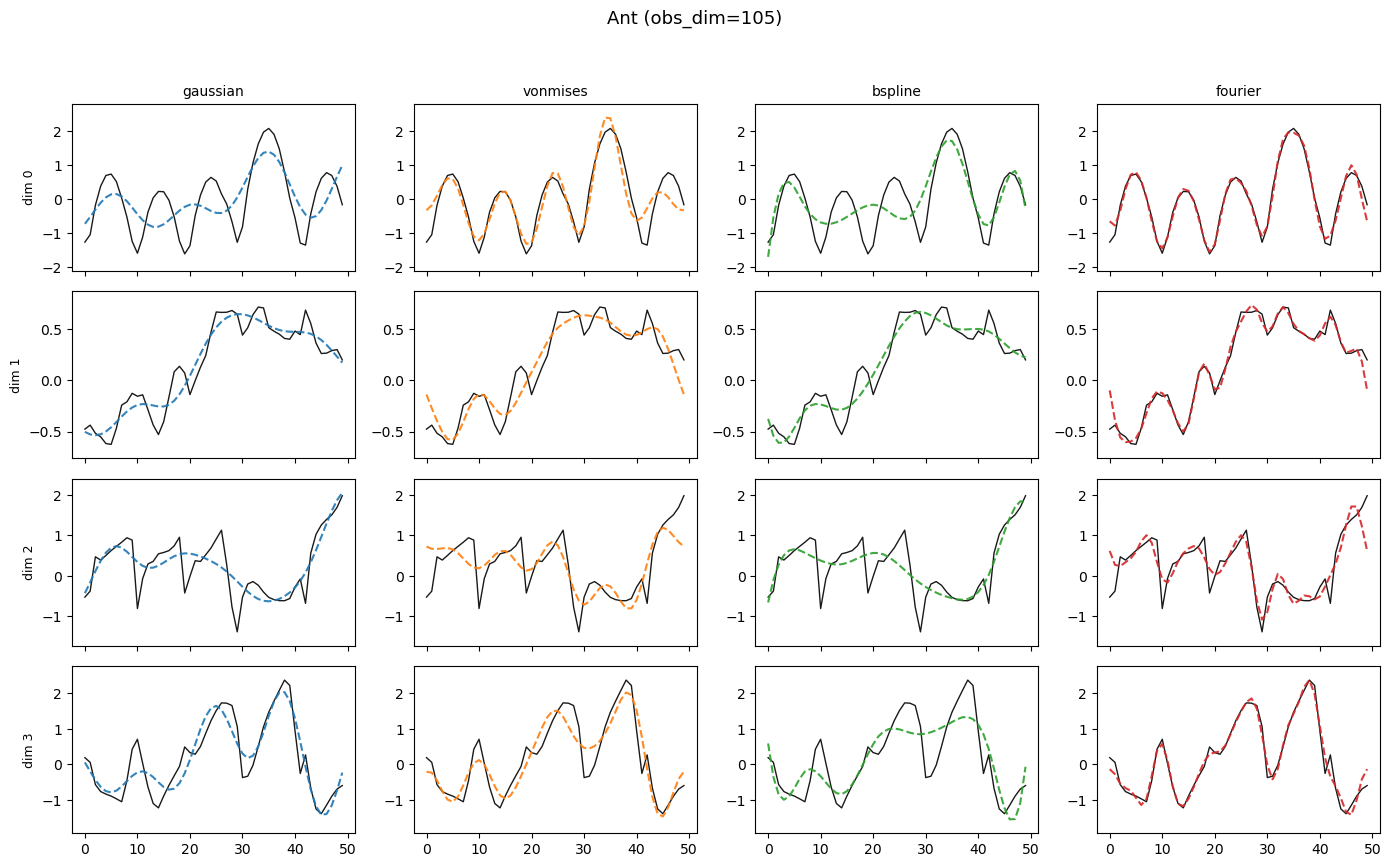

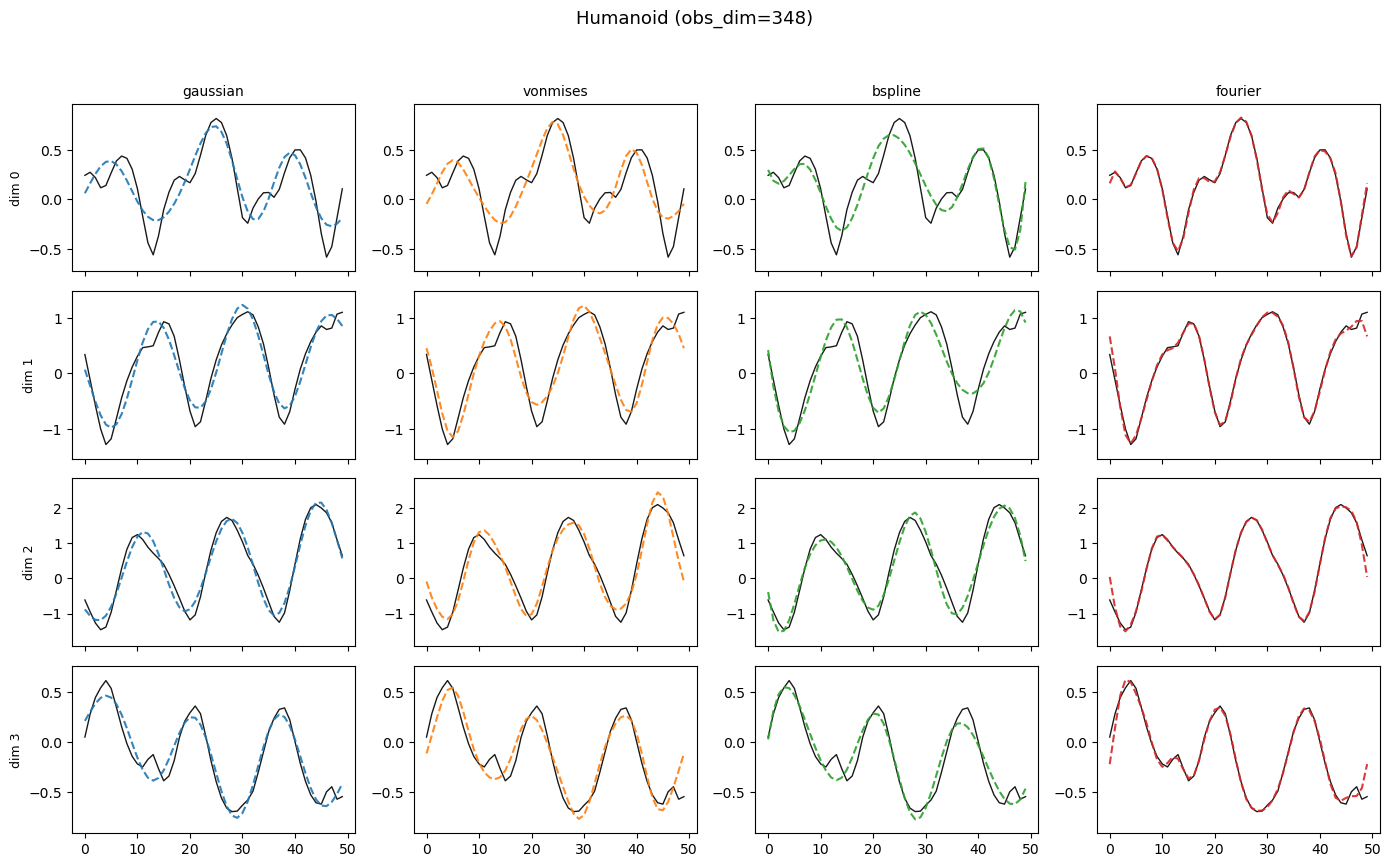

In [135]:
basis_colors = {
    'gaussian': 'tab:blue',
    'vonmises': 'tab:orange',
    'bspline': 'tab:green',
    'fourier': 'tab:red',
}

for env_name, ed in env_data.items():
    windows = ed['example_windows']
    recons = reconstruct_all_bases(windows, ed['obs_dim'], ed['window'])
    plot_dims = ed['plot_dims']
    n_dims_plot = len(plot_dims)
    t_axis = np.arange(ed['window'])

    fig, axes = plt.subplots(
        n_dims_plot, len(BASIS_TYPES),
        figsize=(3.5 * len(BASIS_TYPES), 2.2 * n_dims_plot),
        sharex=True, squeeze=False,
    )
    fig.suptitle(f"{ed['display_name']} (obs_dim={ed['obs_dim']})", fontsize=13)

    for row, dim in enumerate(plot_dims):
        # Compute shared ylim across basis types for this dim
        all_vals = [windows[:, :, dim].ravel()]
        for btype in BASIS_TYPES:
            all_vals.append(recons[btype][:, :, dim].ravel())
        all_vals = np.concatenate(all_vals)
        ymin, ymax = all_vals.min(), all_vals.max()
        margin = 0.1 * max(ymax - ymin, 1e-6)
        ylim = (ymin - margin, ymax + margin)

        for col, btype in enumerate(BASIS_TYPES):
            ax = axes[row, col]
            for wi in range(N_EXAMPLE_WINDOWS):
                alpha = 0.9 - 0.3 * wi
                ax.plot(t_axis, windows[wi, :, dim], 'k-', alpha=alpha, lw=1)
                ax.plot(t_axis, recons[btype][wi, :, dim], '--',
                        color=basis_colors[btype], alpha=alpha, lw=1.5)
            ax.set_ylim(ylim)
            if row == 0:
                ax.set_title(btype, fontsize=10)
            if col == 0:
                ax.set_ylabel(f"dim {dim}", fontsize=9)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [136]:
MAX_NRMSE_WINDOWS = 500

nrmse_rows = []
for env_name, ed in env_data.items():
    windows = ed['all_windows']
    if len(windows) > MAX_NRMSE_WINDOWS:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(windows), MAX_NRMSE_WINDOWS, replace=False)
        windows = windows[idx]

    recons = reconstruct_all_bases(windows, ed['obs_dim'], ed['window'])
    data_std = np.std(windows)

    row = {'Environment': ed['display_name']}
    for btype in BASIS_TYPES:
        rmse = np.sqrt(np.mean((windows - recons[btype]) ** 2))
        row[btype] = rmse / data_std
    nrmse_rows.append(row)

nrmse_df = pd.DataFrame(nrmse_rows).set_index('Environment')
nrmse_df.style.format("{:.4f}").background_gradient(cmap='RdYlGn_r', axis=None)

,gaussian,vonmises,bspline,fourier
Environment,,,,
Inv. Pend.,0.2305,0.2726,0.2436,0.2163
Upkie,0.3234,0.3432,0.3265,0.3151
Hopper,0.1515,0.2542,0.1695,0.1713
Half Cheetah,0.7874,0.7903,0.7772,0.4646
Ant,0.8190,0.8103,0.8214,0.6269
Humanoid,0.5219,0.5314,0.5362,0.3384


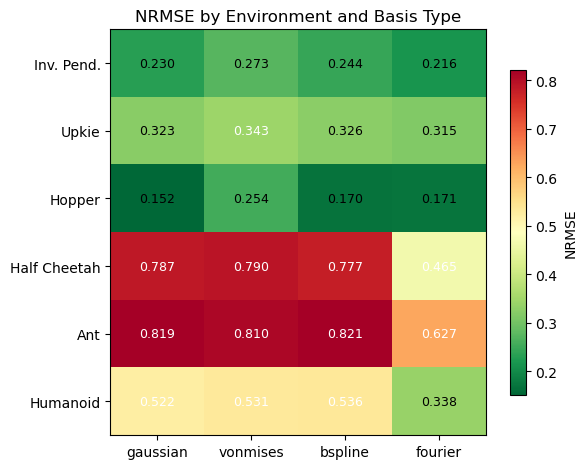

In [137]:
fig, ax = plt.subplots(figsize=(6, 0.6 * len(nrmse_df) + 1.2))
vals = nrmse_df.values
im = ax.imshow(vals, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(BASIS_TYPES)))
ax.set_xticklabels(BASIS_TYPES, fontsize=10)
ax.set_yticks(range(len(nrmse_df)))
ax.set_yticklabels(nrmse_df.index, fontsize=10)

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.3f}", ha='center', va='center', fontsize=9,
                color='white' if vals[i, j] > np.median(vals) else 'black')

ax.set_title("NRMSE by Environment and Basis Type", fontsize=12)
fig.colorbar(im, ax=ax, label='NRMSE', shrink=0.8)
fig.tight_layout()
plt.show()

### Observations

**Low-dim (Inv. Pend., Upkie — 4 obs dims):**
- TODO: note which basis types reconstruct well/poorly

**Medium-dim (Hopper — 11, Half Cheetah — 17):**
- TODO: note reconstruction quality differences

**High-dim (Ant — 105, Humanoid — 376):**
- TODO: note whether basis projection still captures dominant variation

**Note:** Fourier basis produces `2*n_basis + 1 = 11` basis functions per dimension vs 5 for the others, giving it more expressiveness at the cost of a larger weight vector.

Input mean: 0.072995
Recon mean: 0.072958
Max error:  0.579395


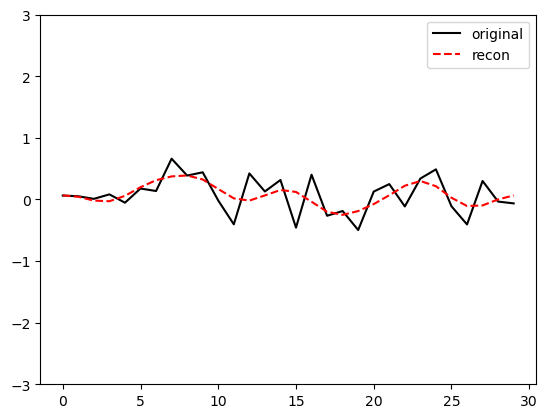

In [138]:
# Quick sanity check: reconstruct a known constant signal                      
test_signal = 0.3 * np.random.randn(1,30,1)  # constant at 3.0
t = np.linspace(0, 1, 30)
proj = BasisProjector(n_dims=1, n_basis=10, basis_type='vonmises', ridge_lambda=1e-6)
W = proj.project(test_signal, t)
Phi = proj.basis._compute_basis_single(t)
recon = np.einsum('tk,ndk->ntd', Phi, W)
print(f"Input mean: {test_signal.mean():.6f}")
print(f"Recon mean: {recon.mean():.6f}")
print(f"Max error:  {np.abs(test_signal - recon).max():.6f}")
plt.plot(test_signal[0,:,0], 'k-', label='original')
plt.plot(recon[0,:,0], 'r--', label='recon')
plt.ylim(-3, 3)
plt.legend()